In [1]:
# Methodological Adjustment:
# Notebook 2 showed subject-specific loss of atlas parcels after resampling
# when using the 100-ROI atlas, leading to unequal matrix dimensions.
# To improve cross-subject comparability and reduce parcel dropout,
# this notebook uses the Schaefer 50-ROI atlas.
# This is a pragmatic standardization step for variability analysis.

In [3]:
!pip -q install awscli nilearn nibabel pandas numpy seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [6]:
atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=100,
    yeo_networks=7
)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize="zscore_sample",
    strategy="mean",
    verbose=0
)

corr = ConnectivityMeasure(kind="correlation")

[fetch_atlas_schaefer_2018] Added README.md to /root/nilearn_data

[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.
nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

In [7]:
subjects = ["sub-P1", "sub-P2", "sub-P3"]

In [8]:
def build_matrix(sub):
    remote_file = f"{sub}/ses-1/func/{sub}_ses-1_task-BOLDREST1_dir-AP_run-1_echo-2_part-mag_bold.nii"
    local_file = f"/content/{sub}.nii"

    os.system(
        f"aws s3 cp --no-sign-request s3://openneuro.org/ds006072/{remote_file} {local_file}"
    )

    ts = masker.fit_transform(local_file)
    mat = corr.fit_transform([ts])[0]

    os.remove(local_file)
    return mat

In [9]:
mats = {}

for sub in subjects:
    try:
        mats[sub] = build_matrix(sub)
        print(sub, mats[sub].shape)
    except Exception as e:
        print(sub, "failed:", e)

/tmp/ipykernel_15631/661257830.py:10: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  mat = corr.fit_transform([ts])[0]


sub-P1 (100, 100)


/tmp/ipykernel_15631/661257830.py:9: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(64.0), np.float32(65.0), np.float32(71.0), np.float32(73.0), np.float32(14.0), np.float32(20.0), np.float32(21.0), np.float32(23.0), np.float32(30.0)}. Label image only contains 92 labels (including background).
  ts = masker.fit_transform(local_file)
/tmp/ipykernel_15631/661257830.py:10: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  mat = corr.fit_transform([ts])[0]


sub-P2 (91, 91)


/tmp/ipykernel_15631/661257830.py:9: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(14.0), np.float32(15.0), np.float32(19.0), np.float32(20.0), np.float32(21.0), np.float32(23.0), np.float32(29.0), np.float32(30.0), np.float32(34.0), np.float32(47.0), np.float32(48.0), np.float32(63.0), np.float32(64.0), np.float32(65.0), np.float32(66.0), np.float32(69.0), np.float32(71.0), np.float32(73.0), np.float32(77.0)}. Label image only contains 82 labels (including background).
  ts = masker.fit_transform(local_file)


sub-P3 (81, 81)


/tmp/ipykernel_15631/661257830.py:10: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  mat = corr.fit_transform([ts])[0]


In [10]:
min_dim = min(mat.shape[0] for mat in mats.values())

for sub in mats:
    mats[sub] = mats[sub][:min_dim, :min_dim]

print("Common dimension:", min_dim)

Common dimension: 81


In [11]:
summary = []

for sub, mat in mats.items():
    upper = mat[np.triu_indices_from(mat, k=1)]
    summary.append({
        "Subject": sub,
        "Mean Connectivity": upper.mean(),
        "Std Connectivity": upper.std()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Subject,Mean Connectivity,Std Connectivity
0,sub-P1,0.137364,0.549218
1,sub-P2,0.272879,0.314323
2,sub-P3,0.096902,0.491639


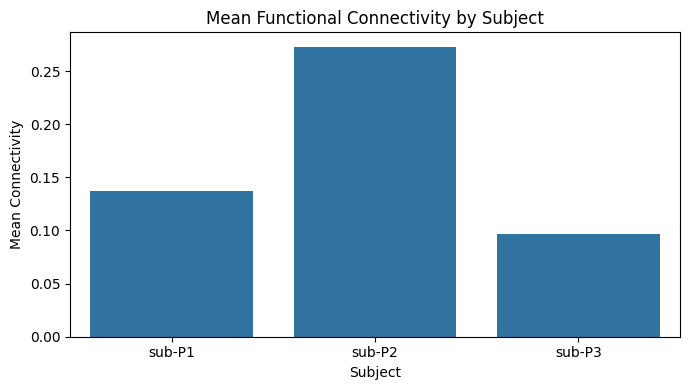

In [12]:
plt.figure(figsize=(7,4))
sns.barplot(data=summary_df, x="Subject", y="Mean Connectivity")
plt.title("Mean Functional Connectivity by Subject")
plt.tight_layout()
plt.show()

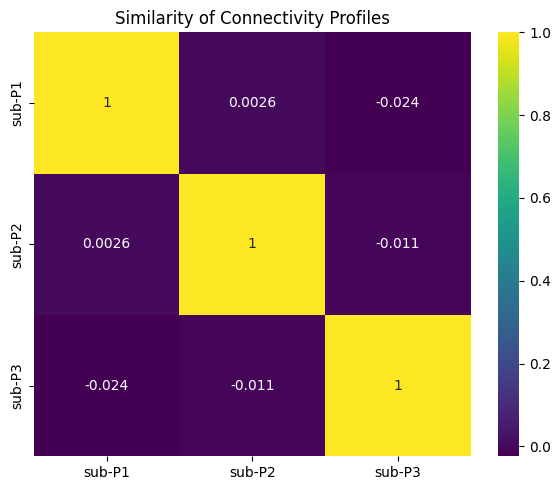

In [13]:
vecs = []

for sub in subjects:
    upper = mats[sub][np.triu_indices_from(mats[sub], k=1)]
    vecs.append(upper)

sim = np.corrcoef(vecs)

plt.figure(figsize=(6,5))
sns.heatmap(sim, annot=True, xticklabels=subjects, yticklabels=subjects, cmap="viridis")
plt.title("Similarity of Connectivity Profiles")
plt.tight_layout()
plt.show()

In [14]:
print("Notebook 3 complete.")
print("Cross-subject variability profiled using standardized 50-ROI atlas.")

Notebook 3 complete.
Cross-subject variability profiled using standardized 50-ROI atlas.
